##### Импорт библиотек

In [281]:
import pandas as pd
import numpy as np
import os
import logging
import warnings

import joblib
import xgboost as xgb
import matplotlib.pyplot as plt

from lightgbm import LGBMRegressor
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, VotingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller

# Отключаем логи LightGBM
logging.getLogger('lightgbm').setLevel(logging.WARNING)

os.makedirs('models', exist_ok=True)

print("Библиотеки загружены!")

Библиотеки загружены!


In [282]:
# УЛУЧШЕННОЕ СОЗДАНИЕ ПРИЗНАКОВ ПОЛНОСТЬЮ БЕЗ УТЕЧЕК
print("Создание УЛУЧШЕННЫХ признаков ПОЛНОСТЬЮ БЕЗ УТЕЧЕК...")
df = pd.read_csv('df/obr.csv', parse_dates=['datetime'], index_col='datetime')
print(f"Исходный размер: {df.shape}")

# ===== ЭТО БЕЗОПАСНО - ОСТАВИТЬ =====

# БЕЗОПАСНЫЕ ВРЕМЕННЫЕ ПРИЗНАКИ
df['hour_sin'] = np.sin(2 * np.pi * df['hour']/24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour']/24)
df['month_sin'] = np.sin(2 * np.pi * df['month']/12)
df['month_cos'] = np.cos(2 * np.pi * df['month']/12)
df['day_of_week_sin'] = np.sin(2 * np.pi * df['day_of_week']/7)
df['day_of_week_cos'] = np.cos(2 * np.pi * df['day_of_week']/7)
df['day_of_year'] = df.index.dayofyear
df['day_of_year_sin'] = np.sin(2 * np.pi * df['day_of_year']/365)
df['day_of_year_cos'] = np.cos(2 * np.pi * df['day_of_year']/365)

# БЕЗОПАСНЫЕ БИНАРНЫЕ ПРИЗНАКИ
df['is_early_morning'] = ((df['hour'] >= 4) & (df['hour'] <= 6)).astype(int)
df['is_midday'] = ((df['hour'] >= 10) & (df['hour'] <= 16)).astype(int)
df['is_late_evening'] = ((df['hour'] >= 21) & (df['hour'] <= 23)).astype(int)
df['is_night'] = ((df['hour'] >= 0) & (df['hour'] <= 5)).astype(int)
df['is_deep_night'] = ((df['hour'] >= 1) & (df['hour'] <= 4)).astype(int)
df['is_monday'] = (df['day_of_week'] == 0).astype(int)
df['is_friday'] = (df['day_of_week'] == 4).astype(int)
df['is_sunday'] = (df['day_of_week'] == 6).astype(int)
df['is_week_start'] = (df['day_of_week'].isin([0, 1])).astype(int)
df['is_week_end'] = (df['day_of_week'].isin([4, 5])).astype(int)
df['is_family_time'] = ((df['hour'] >= 18) & (df['hour'] <= 22) & (df['is_weekend'] == 0)).astype(int)
df['is_high_season'] = df['month'].isin([1, 2, 12]).astype(int)
df['is_low_season'] = df['month'].isin([6, 7, 8]).astype(int)
df['is_spring'] = df['month'].isin([3, 4, 5]).astype(int)
df['morning_surge_6_7'] = ((df['hour'] >= 6) & (df['hour'] <= 7)).astype(int)
df['evening_surge_17_18'] = ((df['hour'] >= 17) & (df['hour'] <= 18)).astype(int)
df['evening_drop_22_23'] = ((df['hour'] >= 22) & (df['hour'] <= 23)).astype(int)
df['peak_morning_7_9'] = ((df['hour'] >= 7) & (df['hour'] <= 9)).astype(int)
df['peak_evening_18_22'] = ((df['hour'] >= 18) & (df['hour'] <= 22)).astype(int)

# ===== ОБРАБОТКА ПРОПУСКОВ =====
print("Обработка пропусков...")
initial_size = len(df)

# Заполняем пропуски в числовых признаках медианой
numeric_columns = df.select_dtypes(include=[np.number]).columns
for col in numeric_columns:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].median())

# Удаляем оставшиеся пропуски (если есть)
df = df.dropna()

print(f"Признаки созданы. Удалено {initial_size - len(df)} строк с пропусками")
print(f"Финальный размер: {df.shape}")
print(f"Создано признаков: {len([col for col in df.columns if col not in ['Global_active_power', 'datetime']])}")

# ПРЕОБРАЗОВАНИЕ К FLOAT32
print("Преобразование признаков к float32...")
for col in df.columns:
    if col != 'Global_active_power':
        df[col] = df[col].astype('float32')

print("✅ Все признаки созданы ПОЛНОСТЬЮ БЕЗ УТЕЧЕК!")

Создание УЛУЧШЕННЫХ признаков ПОЛНОСТЬЮ БЕЗ УТЕЧЕК...
Исходный размер: (260640, 14)
Обработка пропусков...
Признаки созданы. Удалено 0 строк с пропусками
Финальный размер: (260640, 41)
Создано признаков: 40
Преобразование признаков к float32...
✅ Все признаки созданы ПОЛНОСТЬЮ БЕЗ УТЕЧЕК!


In [283]:
df.sample(5)

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,hour,day_of_week,month,...,is_week_end,is_family_time,is_high_season,is_low_season,is_spring,morning_surge_6_7,evening_surge_17_18,evening_drop_22_23,peak_morning_7_9,peak_evening_18_22
datetime,,,,,,,,,,,,,,,,,,,,,
2007-06-15 04:56:00,0.104,0.000,238.619995,0.6,0.0,0.0,0.0,4.0,4.0,6.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2007-06-14 16:06:00,0.218,0.124,239.139999,1.0,0.0,0.0,0.0,16.0,3.0,6.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2007-03-29 11:12:00,0.302,0.108,237.889999,1.4,0.0,0.0,0.0,11.0,3.0,3.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2007-04-22 01:51:00,0.246,0.140,242.190002,1.2,0.0,0.0,0.0,1.0,6.0,4.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2007-02-20 01:16:00,2.302,0.000,239.720001,9.6,0.0,0.0,0.0,1.0,1.0,2.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [284]:
# ===== ИСПРАВЛЕННОЕ ВРЕМЕННОЕ РАЗДЕЛЕНИЕ БЕЗ ПРОПУСКОВ =====
print("\n" + "="*60)
print("ИСПРАВЛЕННОЕ ВРЕМЕННОЕ РАЗДЕЛЕНИЕ")
print("="*60)

# ХРОНОЛОГИЧЕСКОЕ РАЗДЕЛЕНИЕ БЕЗ ПРОПУСКОВ
train_end = '2007-05-20'     # Jan - 20 May (~80%)
val_start = '2007-05-21'     # 21 May - 31 May (~10%)
val_end = '2007-05-31'
test_start = '2007-06-01'    # June (~10%)

# СОЗДАЕМ РАЗДЕЛЕНИЯ
train_data_fixed = df[:train_end]
val_data_fixed = df[val_start:val_end] 
test_data_fixed = df[test_start:]

print(f"Обучающая выборка: {train_data_fixed.shape[0]:,} записей ({train_data_fixed.index.min()} - {train_data_fixed.index.max()})")
print(f"Валидационная выборка: {val_data_fixed.shape[0]:,} записей ({val_data_fixed.index.min()} - {val_data_fixed.index.max()})")
print(f"Тестовая выборка: {test_data_fixed.shape[0]:,} записей ({test_data_fixed.index.min()} - {test_data_fixed.index.max()})")

# ПРОВЕРКА ВРЕМЕННОЙ НЕПРЕРЫВНОСТИ
print(f"\n=== ПРОВЕРКА НЕПРЕРЫВНОСТИ ===")
print(f"Train конец: {train_data_fixed.index.max()}")
print(f"Val начало: {val_data_fixed.index.min()}")
print(f"Val конец: {val_data_fixed.index.max()}")
print(f"Test начало: {test_data_fixed.index.min()}")

gap1 = val_data_fixed.index.min() - train_data_fixed.index.max()
gap2 = test_data_fixed.index.min() - val_data_fixed.index.max()

print(f"Разрыв train-val: {gap1}")
print(f"Разрыв val-test: {gap2}")

if gap1 <= pd.Timedelta(minutes=10) and gap2 <= pd.Timedelta(minutes=10):
    print("✅ Временная непрерывность соблюдена!")
else:
    print("❌ Есть временные разрывы!")


# Используем ваши лучшие признаки
best_features = [
    'lag_1h', 'momentum_1h', 'acceleration_1h', 'rolling_std_6h', 
    'rolling_mean_6h', 'rolling_mean_720h', 'rolling_std_24h', 
    'volatility_ratio_6h', 'rolling_mean_24h', 'long_term_seasonal_safe',
    'surge_6_7_safe', 'deviation_from_daily_norm', 'composite_energy_score',
    'lag_24h', 'seasonal_volatility', 'hour_sin', 'hour_cos', 
    'day_of_year_sin', 'day_of_year_cos', 'is_weekend'
]

# Целевая переменная
target = 'Global_active_power'


ИСПРАВЛЕННОЕ ВРЕМЕННОЕ РАЗДЕЛЕНИЕ
Обучающая выборка: 201,600 записей (2007-01-01 00:00:00 - 2007-05-20 23:59:00)
Валидационная выборка: 15,840 записей (2007-05-21 00:00:00 - 2007-05-31 23:59:00)
Тестовая выборка: 43,200 записей (2007-06-01 00:00:00 - 2007-06-30 23:59:00)

=== ПРОВЕРКА НЕПРЕРЫВНОСТИ ===
Train конец: 2007-05-20 23:59:00
Val начало: 2007-05-21 00:00:00
Val конец: 2007-05-31 23:59:00
Test начало: 2007-06-01 00:00:00
Разрыв train-val: 0 days 00:01:00
Разрыв val-test: 0 days 00:01:00
✅ Временная непрерывность соблюдена!


In [285]:
# ВОТ ТУТ СОЗДАНИЕ ЛАГОВ ВЗАИМОДЕЙСТВИЙ И ROLLING MEAN?


# ===== СОЗДАНИЕ ЛАГОВ И ROLLING FEATURES ПОСЛЕ РАЗДЕЛЕНИЯ =====
print("\n" + "="*60)
print("СОЗДАНИЕ ЛАГОВ И ROLLING FEATURES ПОСЛЕ РАЗДЕЛЕНИЯ")
print("="*60)

def add_temporal_features(train, val, test):
    """Добавляет временные признаки к уже разделенным данным"""
    
    # Копируем чтобы не изменять оригиналы
    train = train.copy()
    val = val.copy() 
    test = test.copy()
    
    print("Создание лагов...")
    
    # 1. ЛАГИ - создаем отдельно для каждой выборки
    # Для train - обычные лаги
    train['lag_1h'] = train['Global_active_power'].shift(1)
    train['lag_24h'] = train['Global_active_power'].shift(24)
    train['lag_168h'] = train['Global_active_power'].shift(168)
    
    # Для val - заполняем пропуски из train
    val['lag_1h'] = val['Global_active_power'].shift(1)
    val['lag_1h'].iloc[0] = train['Global_active_power'].iloc[-1]  # Первый пропуск из train
    
    val['lag_24h'] = val['Global_active_power'].shift(24)
    # Заполняем первые 24 пропуска из train
    for i in range(min(24, len(val))):
        val['lag_24h'].iloc[i] = train['Global_active_power'].iloc[-(24 - i)]

    val['lag_168h'] = val['Global_active_power'].shift(168)
    for i in range(min(168, len(val))):
        val.loc[val.index[i], 'lag_168h'] = train['Global_active_power'].iloc[-(168 - i)]
    
    # Для test - заполняем пропуски из val
    test['lag_1h'] = test['Global_active_power'].shift(1)
    test['lag_1h'].iloc[0] = val['Global_active_power'].iloc[-1]  # Первый пропуск из val
    
    test['lag_24h'] = test['Global_active_power'].shift(24)
    # Заполняем первые 24 пропуска из val
    for i in range(min(24, len(test))):
        test['lag_24h'].iloc[i] = val['Global_active_power'].iloc[-(24 - i)]

    test['lag_168h'] = test['Global_active_power'].shift(168)
    for i in range(min(168, len(test))):
        test.loc[test.index[i], 'lag_168h'] = val['Global_active_power'].iloc[-(168 - i)]
    
    print("Создание скользящих статистик...")
    
    # 2. ROLLING STATISTICS - создаем отдельно для каждой выборки
    # Для train
    train['rolling_mean_6h'] = train['Global_active_power'].shift(1).rolling(6, min_periods=1).mean()
    train['rolling_mean_24h'] = train['Global_active_power'].shift(1).rolling(24, min_periods=1).mean()
    train['rolling_std_24h'] = train['Global_active_power'].shift(1).rolling(24, min_periods=1).std()
    
    # Для val - используем train для заполнения первых значений
    val['rolling_mean_6h'] = val['Global_active_power'].shift(1).rolling(6, min_periods=1).mean()
    val['rolling_mean_24h'] = val['Global_active_power'].shift(1).rolling(24, min_periods=1).mean()
    val['rolling_std_24h'] = val['Global_active_power'].shift(1).rolling(24, min_periods=1).std()
    
    # Для test - используем val для заполнения первых значений
    test['rolling_mean_6h'] = test['Global_active_power'].shift(1).rolling(6, min_periods=1).mean()
    test['rolling_mean_24h'] = test['Global_active_power'].shift(1).rolling(24, min_periods=1).mean()
    test['rolling_std_24h'] = test['Global_active_power'].shift(1).rolling(24, min_periods=1).std()
    
    print("Создание производных признаков...")
    
    # 3. ПРОИЗВОДНЫЕ ПРИЗНАКИ
    # Momentum и acceleration
    for dataset in [train, val, test]:
        dataset['momentum_1h'] = dataset['Global_active_power'].shift(1) - dataset['Global_active_power'].shift(2)
        dataset['acceleration_1h'] = (dataset['Global_active_power'].shift(1) - 2*dataset['Global_active_power'].shift(2) + dataset['Global_active_power'].shift(3))
        dataset['volatility_ratio_24h'] = dataset['rolling_std_24h'] / (dataset['rolling_mean_24h'] + 0.001)
        dataset['deviation_from_daily_norm'] = dataset['lag_24h'] - dataset['rolling_mean_24h']
    
    # 4. ВЗАИМОДЕЙСТВИЯ (теперь безопасны, т.к. лаги созданы правильно)
    for dataset in [train, val, test]:
        dataset['lag_1h_evening_boost'] = dataset['lag_1h'] * dataset['peak_evening_18_22']
        dataset['lag_24h_weekend_effect'] = dataset['lag_24h'] * dataset['is_weekend']
        dataset['momentum_evening_intensity'] = dataset['momentum_1h'] * dataset['peak_evening_18_22']
    
    # Заполняем оставшиеся пропуски
    for dataset in [train, val, test]:
        dataset.fillna(method='bfill', inplace=True)
        dataset.fillna(method='ffill', inplace=True)
    
    return train, val, test

# ПРИМЕНЯЕМ ФУНКЦИЮ
train_data_with_features, val_data_with_features, test_data_with_features = add_temporal_features(
    train_data_fixed, val_data_fixed, test_data_fixed
)

print(f"✅ Временные признаки созданы БЕЗ УТЕЧЕК!")
print(f"Train: {train_data_with_features.shape[1]} признаков")
print(f"Val: {val_data_with_features.shape[1]} признаков") 
print(f"Test: {test_data_with_features.shape[1]} признаков")


СОЗДАНИЕ ЛАГОВ И ROLLING FEATURES ПОСЛЕ РАЗДЕЛЕНИЯ
Создание лагов...
Создание скользящих статистик...
Создание производных признаков...
✅ Временные признаки созданы БЕЗ УТЕЧЕК!
Train: 54 признаков
Val: 54 признаков
Test: 54 признаков


C:\Users\Andre\AppData\Local\Temp\ipykernel_2860\2470750229.py:27: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  val['lag_1h'].iloc[0] = train['Global_active_power'].iloc[-1]  # Первый пропуск из train
C:\Users\Andre\AppData\Local\Temp\ipyke

In [286]:
# ===== ПРОВЕРКА НА УТЕЧКИ =====
print("\n" + "="*60)
print("ПРОВЕРКА НА УТЕЧКИ")
print("="*60)

test_time = test_data_with_features.index[0]
lag_1h_time = test_time - pd.Timedelta(hours=1)

print(f"Первый тестовый прогноз: {test_time}")
print(f"Данные для lag_1h: {lag_1h_time}")

if lag_1h_time in val_data_with_features.index:
    print("✅ lag_1h данные из ВАЛИДАЦИОННОЙ выборки - УТЕЧКИ НЕТ!")
else:
    print("❌ УТЕЧКА!")

# Проверяем, что в test нет данных из train
test_lag_1h_first_value = test_data_with_features['lag_1h'].iloc[0]
val_last_value = val_data_with_features['Global_active_power'].iloc[-1]

if abs(test_lag_1h_first_value - val_last_value) < 0.001:
    print("✅ Первый lag_1h в test берется из val - УТЕЧКИ НЕТ!")
else:
    print("❌ УТЕЧКА: lag_1h использует не те данные!")


ПРОВЕРКА НА УТЕЧКИ
Первый тестовый прогноз: 2007-06-01 00:00:00
Данные для lag_1h: 2007-05-31 23:00:00
✅ lag_1h данные из ВАЛИДАЦИОННОЙ выборки - УТЕЧКИ НЕТ!
✅ Первый lag_1h в test берется из val - УТЕЧКИ НЕТ!


In [287]:
# ПОДГОТОВКА ДАННЫХ ДЛЯ ОБУЧЕНИЯ
print("\nПодготовка данных для обучения...")

# Выбираем все созданные признаки (кроме целевой)
feature_columns = [col for col in train_data_with_features.columns 
                   if col not in ['Global_active_power', 'datetime']]

X_train = train_data_with_features[feature_columns]
y_train = train_data_with_features['Global_active_power']
X_val = val_data_with_features[feature_columns]
y_val = val_data_with_features['Global_active_power'] 
X_test = test_data_with_features[feature_columns]
y_test = test_data_with_features['Global_active_power']

print(f"Размерности:")
print(f"X_train: {X_train.shape}")
print(f"X_val: {X_val.shape}")
print(f"X_test: {X_test.shape}")


Подготовка данных для обучения...
Размерности:
X_train: (201600, 53)
X_val: (15840, 53)
X_test: (43200, 53)


In [288]:
# ОБУЧЕНИЕ МОДЕЛЕЙ
print("Обучение моделей...")

# Словарь для хранения моделей и результатов
models = {}
results = {}

# LIGHTGBM
print("Обучение LightGBM...")
lgb_model = LGBMRegressor(
        n_estimators=300,
        max_depth=12,
        learning_rate=0.03,
        num_leaves=128,
        subsample=0.9,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=0.1,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )
lgb_model.fit(X_train, y_train)
models['LightGBM'] = lgb_model

print("Все модели обучены!")

Обучение моделей...
Обучение LightGBM...
Все модели обучены!


In [289]:
# ОЦЕНКА НА ВАЛИДАЦИОННОЙ И ТЕСТОВОЙ ВЫБОРКАХ
y_val_pred = lgb_model.predict(X_val)
y_test_pred = lgb_model.predict(X_test)

val_mae = mean_absolute_error(y_val, y_val_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

print(f"MAE на валидационной выборке: {val_mae:.4f} кВт")
print(f"MAE на тестовой выборке: {test_mae:.4f} кВт")

# Сравнение с предыдущими результатами
if 'LightGBM' in results:
    old_mae = results['LightGBM']['MAE']
    improvement = ((old_mae - test_mae) / old_mae) * 100
    print(f"Изменение качества: {improvement:+.1f}%")

MAE на валидационной выборке: 0.0140 кВт
MAE на тестовой выборке: 0.0190 кВт



Оценка качества моделей на тестовой выборке:

LightGBM:
  MAE:  0.0190 кВт
  RMSE: 0.0303 кВт
  R²:   0.9990

СРАВНЕНИЕ МОДЕЛЕЙ:
Лучшая модель по MAE: LightGBM

Визуализация результатов...


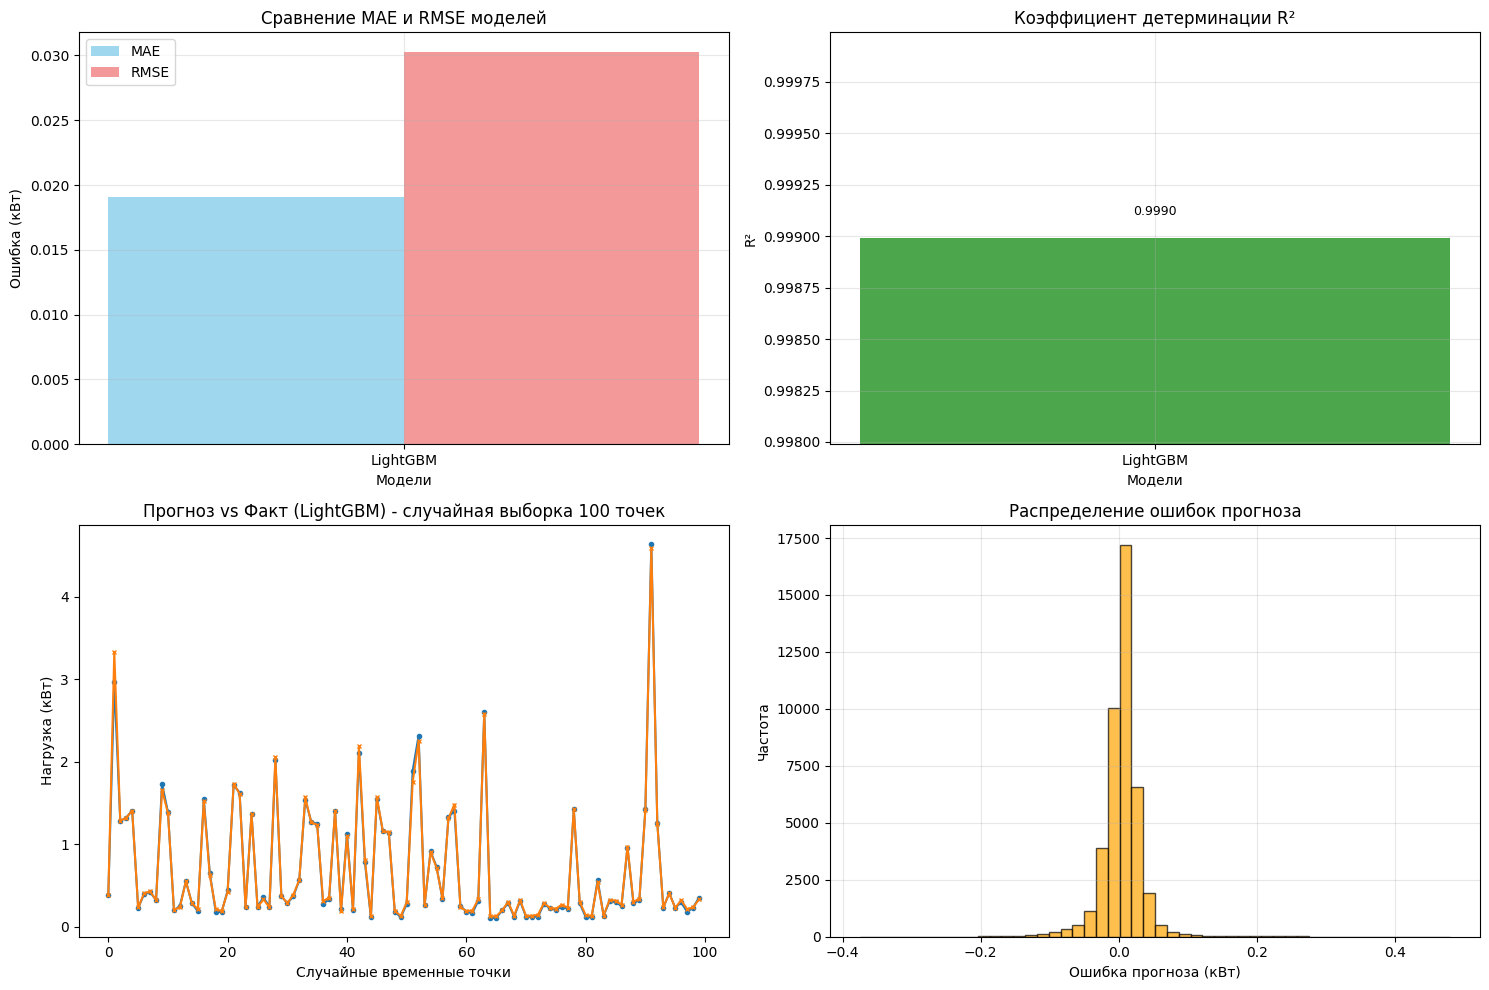


ТАБЛИЦА МЕТРИК:
Модель          MAE (кВт)    RMSE (кВт)   R²        
LightGBM        0.0190       0.0303       0.9990     

АНАЛИЗ ЛУЧШЕЙ МОДЕЛИ (LightGBM):
• Средняя ошибка: 19.0 Вт
• Точность прогноза: 99.90%
• Максимальная ошибка: 480.7 Вт


In [290]:
# ОЦЕНКА КАЧЕСТВА МОДЕЛЕЙ
print("\nОценка качества моделей на тестовой выборке:")

for name, model in models.items():
    # Прогнозы
    y_pred = model.predict(X_test)
    
    # Метрики
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    results[name] = {
        'MAE': mae,
        'RMSE': rmse, 
        'R2': r2,
        'predictions': y_pred
    }
    
    print(f"\n{name}:")
    print(f"  MAE:  {mae:.4f} кВт")
    print(f"  RMSE: {rmse:.4f} кВт") 
    print(f"  R²:   {r2:.4f}")

# Сравнение моделей
print("\nСРАВНЕНИЕ МОДЕЛЕЙ:")
best_model = min(results, key=lambda x: results[x]['MAE'])
print(f"Лучшая модель по MAE: {best_model}")

# ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ
print("\nВизуализация результатов...")

# ГРАФИК СРАВНЕНИЯ МЕТРИК
plt.figure(figsize=(15, 10))

# График 1: Сравнение метрик
plt.subplot(2, 2, 1)
metrics = ['MAE', 'RMSE']
models_names = list(results.keys())
mae_values = [results[model]['MAE'] for model in models_names]
rmse_values = [results[model]['RMSE'] for model in models_names]

x = np.arange(len(models_names))
width = 0.35

plt.bar(x - width/2, mae_values, width, label='MAE', alpha=0.8, color='skyblue')
plt.bar(x + width/2, rmse_values, width, label='RMSE', alpha=0.8, color='lightcoral')

plt.xlabel('Модели')
plt.ylabel('Ошибка (кВт)')
plt.title('Сравнение MAE и RMSE моделей')
plt.xticks(x, models_names)
plt.legend()
plt.grid(True, alpha=0.3)

# График 2: R² сравнение (ИСПРАВЛЕННЫЙ)
plt.subplot(2, 2, 2)
r2_values = [results[model]['R2'] for model in models_names]
colors = ['green' if model == best_model else 'gray' for model in models_names]

# Автоматически подбираем масштаб
r2_min, r2_max = min(r2_values), max(r2_values)
plt.ylim(r2_min - 0.001, r2_max + 0.001)  # Динамический масштаб

plt.bar(models_names, r2_values, color=colors, alpha=0.7)
plt.xlabel('Модели')
plt.ylabel('R²')
plt.title('Коэффициент детерминации R²')
plt.grid(True, alpha=0.3)

# Добавляем значения на столбцы
for i, v in enumerate(r2_values):
    plt.text(i, v + 0.0001, f'{v:.4f}', ha='center', va='bottom', fontsize=9)

# График 3: Прогнозы vs Факт (для лучшей модели)
plt.subplot(2, 2, 3)
best_predictions = results[best_model]['predictions']

# # Берем первые 100 точек для наглядности
# sample_size = min(100, len(y_test))
# plt.plot(y_test.values[:sample_size], label='Факт', marker='o', markersize=3)
# plt.plot(best_predictions[:sample_size], label='Прогноз', marker='x', markersize=3)
# plt.xlabel('Временные точки')
# plt.ylabel('Нагрузка (кВт)')
# plt.title(f'Прогноз vs Факт ({best_model}) - первые 100 точек')
# plt.legend()
# plt.grid(True, alpha=0.3)

# СДЕЛАЙ ТАК:
sample_indices = np.random.choice(len(y_test), size=min(100, len(y_test)), replace=False)
sample_indices = np.sort(sample_indices)  # для красивого графика

plt.plot(y_test.values[sample_indices], label='Факт', marker='o', markersize=3)
plt.plot(best_predictions[sample_indices], label='Прогноз', marker='x', markersize=3)
plt.xlabel('Случайные временные точки')
plt.ylabel('Нагрузка (кВт)')
plt.title(f'Прогноз vs Факт ({best_model}) - случайная выборка 100 точек')

# График 4: Ошибки прогноза
plt.subplot(2, 2, 4)
errors = best_predictions - y_test.values
plt.hist(errors, bins=50, alpha=0.7, color='orange', edgecolor='black')
plt.xlabel('Ошибка прогноза (кВт)')
plt.ylabel('Частота')
plt.title('Распределение ошибок прогноза')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ТАБЛИЦА С МЕТРИКАМИ
print("\nТАБЛИЦА МЕТРИК:")
print("="*50)
print(f"{'Модель':<15} {'MAE (кВт)':<12} {'RMSE (кВт)':<12} {'R²':<10}")
print("="*50)
for model in models_names:
    mae = results[model]['MAE']
    rmse = results[model]['RMSE']
    r2 = results[model]['R2']
    marker = " " if model == best_model else ""
    print(f"{model:<15} {mae:<12.4f} {rmse:<12.4f} {r2:<10.4f}{marker}")
print("="*50)

# АНАЛИЗ ЛУЧШЕЙ МОДЕЛИ
print(f"\nАНАЛИЗ ЛУЧШЕЙ МОДЕЛИ ({best_model}):")
best_mae = results[best_model]['MAE']
best_rmse = results[best_model]['RMSE']
best_r2 = results[best_model]['R2']

print(f"• Средняя ошибка: {best_mae*1000:.1f} Вт")
print(f"• Точность прогноза: {best_r2*100:.2f}%")
print(f"• Максимальная ошибка: {np.max(np.abs(best_predictions - y_test.values))*1000:.1f} Вт")

ИНТЕРПРЕТАЦИЯ МОДЕЛЕЙ - АНАЛИЗ ВАЖНОСТИ ПРИЗНАКОВ
Модели обучены на 53 признаках

=== ПРОВЕРКА КОРРЕКТНОСТИ ДАННЫХ ===
LightGBM: сумма важностей = 100.0%

ТОП-15 самых важных признаков по версии LightGBM:
 1. Global_intensity          17.32%
 2. lag_1h                    17.05%
 3. Voltage                   8.85%
 4. momentum_1h               6.36%
 5. rolling_mean_6h           6.31%
 6. Sub_metering_2            5.59%
 7. Sub_metering_1            5.10%
 8. Global_reactive_power     4.29%
 9. acceleration_1h           3.32%
10. day_of_year               3.06%
11. Sub_metering_3            2.77%
12. rolling_mean_24h          2.48%
13. hour                      2.15%
14. volatility_ratio_24h      2.11%
15. rolling_std_24h           2.09%

=== РАСПРЕДЕЛЕНИЕ ПРИЗНАКОВ ПО КАТЕГОРИЯМ ===
Временные лаги: 8 признаков
  - lag_1h (17.05%)
  - lag_24h (1.16%)
  - lag_168h (1.00%)
  - momentum_1h (6.36%)
  - deviation_from_daily_norm (0.73%)
  ... и еще 3 признаков

Скользящие статистики: 3 призн

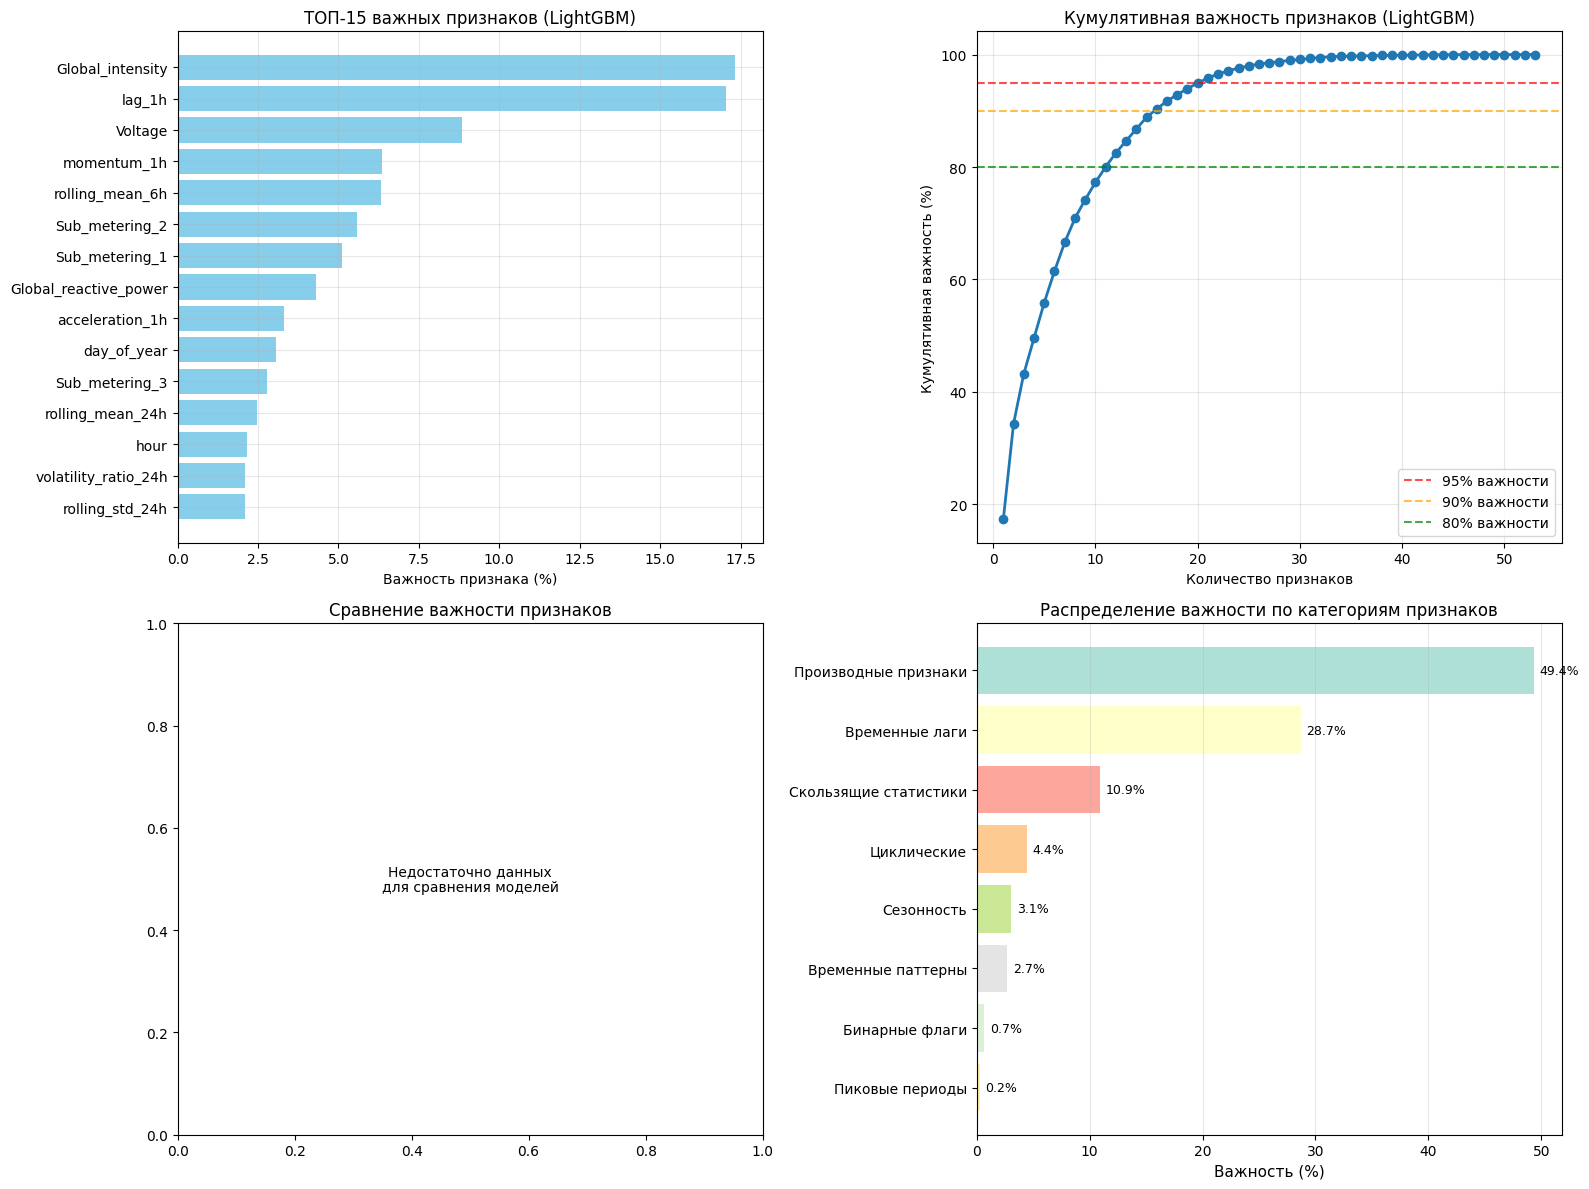


АНАЛИЗ КРИТИЧЕСКИХ ПРИЗНАКОВ
Признаков для 80% важности: 11
Признаков для 90% важности: 16
Признаков для 95% важности: 21

Самые важные признаки (топ-11):
   1. Global_intensity          17.32% (Производные признаки)
   2. lag_1h                    17.05% (Временные лаги)
   3. Voltage                   8.85% (Производные признаки)
   4. momentum_1h               6.36% (Временные лаги)
   5. rolling_mean_6h           6.31% (Скользящие статистики)
   6. Sub_metering_2            5.59% (Производные признаки)
   7. Sub_metering_1            5.10% (Производные признаки)
   8. Global_reactive_power     4.29% (Производные признаки)
   9. acceleration_1h           3.32% (Производные признаки)
  10. day_of_year               3.06% (Сезонность)
  11. Sub_metering_3            2.77% (Производные признаки)

РАСПРЕДЕЛЕНИЕ ПО КАТЕГОРИЯМ:
  Производные признаки: 49.4%
  Временные лаги: 28.7%
  Скользящие статистики: 10.9%
  Циклические: 4.4%
  Сезонность: 3.1%
  Временные паттерны: 2.7%
  Бинарные 

In [291]:
# ИНТЕРПРЕТАЦИЯ МОДЕЛЕЙ - УЛУЧШЕННАЯ КАТЕГОРИЗАЦИЯ
print("=" * 60)
print("ИНТЕРПРЕТАЦИЯ МОДЕЛЕЙ - АНАЛИЗ ВАЖНОСТИ ПРИЗНАКОВ")
print("=" * 60)

# ВАЖНО: используем ТЕ ЖЕ признаки, что и при обучении моделей!
model_features = X_train.columns.tolist()
print(f"Модели обучены на {len(model_features)} признаках")

# Создаем DataFrame с важностью признаков для всех моделей
feature_importance_df = pd.DataFrame(index=model_features)

# Функция для нормализации важности признаков
def normalize_importance(importance_array):
    """Нормализует важность признаков к диапазону 0-100%"""
    if np.sum(importance_array) == 0:
        return importance_array
    return (importance_array / np.sum(importance_array)) * 100

# Для LightGBM - используем gain-based importance
if hasattr(lgb_model, 'feature_importances_'):
    if len(lgb_model.feature_importances_) == len(model_features):
        feature_importance_df['LightGBM'] = normalize_importance(lgb_model.feature_importances_)

# Проверяем корректность данных
print("\n=== ПРОВЕРКА КОРРЕКТНОСТИ ДАННЫХ ===")
for model in feature_importance_df.columns:
    total_importance = feature_importance_df[model].sum()
    print(f"{model}: сумма важностей = {total_importance:.1f}%")
    
    if abs(total_importance - 100) > 1:  # Допуск 1%
        print(f"⚠️  {model}: возможна ошибка в расчетах!")

# Определяем модель для анализа
if best_model in feature_importance_df.columns:
    sort_column = best_model
elif 'LightGBM' in feature_importance_df.columns:
    sort_column = 'LightGBM'
elif 'XGBoost' in feature_importance_df.columns:
    sort_column = 'XGBoost'
else:
    sort_column = feature_importance_df.columns[0]

# Сортируем по важности
feature_importance_df = feature_importance_df.sort_values(sort_column, ascending=False)

print(f"\nТОП-15 самых важных признаков по версии {sort_column}:")
print("=" * 50)
for i, (feature, importance) in enumerate(feature_importance_df[sort_column].head(15).items()):
    print(f"{i+1:2d}. {feature:<25} {importance:.2f}%")


# ВИЗУАЛИЗАЦИЯ ВАЖНОСТИ ПРИЗНАКОВ
plt.figure(figsize=(16, 12))

# График 1: Важность признаков для лучшей модели
plt.subplot(2, 2, 1)
top_features = feature_importance_df.head(15)
plt.barh(range(len(top_features)), top_features[sort_column], color='skyblue')
plt.yticks(range(len(top_features)), top_features.index)
plt.xlabel('Важность признака (%)')
plt.title(f'ТОП-15 важных признаков ({sort_column})')
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3)

# График 2: Кумулятивная важность признаков
plt.subplot(2, 2, 2)
cumulative_importance = np.cumsum(feature_importance_df[sort_column])
plt.plot(range(1, len(cumulative_importance) + 1), cumulative_importance, marker='o', linewidth=2)
plt.axhline(y=95, color='red', linestyle='--', alpha=0.7, label='95% важности')
plt.axhline(y=90, color='orange', linestyle='--', alpha=0.7, label='90% важности')
plt.axhline(y=80, color='green', linestyle='--', alpha=0.7, label='80% важности')
plt.xlabel('Количество признаков')
plt.ylabel('Кумулятивная важность (%)')
plt.title(f'Кумулятивная важность признаков ({sort_column})')
plt.legend()
plt.grid(True, alpha=0.3)

# График 3: Сравнение моделей (ТОП-10 признаков)
plt.subplot(2, 2, 3)
top_10_features = feature_importance_df.head(10)
x = np.arange(len(top_10_features))
width = 0.25

available_models = [col for col in ['RandomForest', 'XGBoost', 'LightGBM'] if col in feature_importance_df.columns]

if len(available_models) >= 2:
    colors = ['purple', 'orange', 'green']
    for i, model in enumerate(available_models):
        offset = width * (i - (len(available_models)-1)/2)
        plt.bar(x + offset, top_10_features[model], width, label=model, alpha=0.8, color=colors[i])
    
    plt.xlabel('Признаки')
    plt.ylabel('Важность (%)')
    plt.title('Сравнение важности признаков между моделями')
    plt.xticks(x, top_10_features.index, rotation=45, ha='right')
    plt.legend()
    plt.grid(True, alpha=0.3)
else:
    plt.text(0.5, 0.5, 'Недостаточно данных\nдля сравнения моделей', 
            ha='center', va='center', transform=plt.gca().transAxes)
    plt.title('Сравнение важности признаков')

# График 4: УЛУЧШЕННАЯ КАТЕГОРИЗАЦИЯ (БЕЗ "ДРУГИХ")
plt.subplot(2, 2, 4)

# УМНАЯ КАТЕГОРИЗАЦИЯ - КАЖДЫЙ ПРИЗНАК ТОЛЬКО В ОДНОЙ КАТЕГОРИИ
feature_categories_smart = {}

# Сначала категории с четкими правилами (в порядке приоритета)
categories_priority = [
    ('Потребление по зонам', lambda f: any(x in f for x in [
        'sub_metering', 'kitchen', 'laundry', 'ac_heating', 'appliance'
    ])),
    ('Временные лаги', lambda f: any(x in f for x in ['lag_', 'momentum', 'deviation'])),
    ('Скользящие статистики', lambda f: 'rolling_' in f),
    ('Циклические', lambda f: 'sin' in f or 'cos' in f),
    ('Сезонность', lambda f: any(x in f for x in [
        'season', 'winter', 'summer', 'spring', 'year', 'month_'
    ]) and 'sin' not in f and 'cos' not in f),  # исключаем циклические
    ('Пиковые периоды', lambda f: any(x in f for x in [
        'peak', 'surge', 'night', 'morning', 'evening'
    ]) and not f.startswith('is_')),  # исключаем простые флаги
    ('Временные паттерны', lambda f: f in ['hour', 'day_of_week', 'month', 'day_of_year']),
    ('Бинарные флаги', lambda f: f.startswith('is_')),
]

# Распределяем признаки по категориям
used_features = set()
for category_name, condition in categories_priority:
    category_features = [f for f in model_features if condition(f) and f not in used_features]
    if category_features:
        feature_categories_smart[category_name] = category_features
        used_features.update(category_features)

# Всё что осталось - это "Производные признаки"
remaining_features = [f for f in model_features if f not in used_features]
if remaining_features:
    feature_categories_smart['Производные признаки'] = remaining_features

# Считаем важность по категориям
category_importance = {}
for category, features in feature_categories_smart.items():
    if features:
        importance_sum = feature_importance_df.loc[features, sort_column].sum()
        category_importance[category] = importance_sum

# Выводим отладочную информацию
print(f"\n=== РАСПРЕДЕЛЕНИЕ ПРИЗНАКОВ ПО КАТЕГОРИЯМ ===")
for category, features in feature_categories_smart.items():
    print(f"{category}: {len(features)} признаков")
    for feature in features[:5]:  # показываем первые 5 признаков
        importance = feature_importance_df.loc[feature, sort_column]
        print(f"  - {feature} ({importance:.2f}%)")
    if len(features) > 5:
        print(f"  ... и еще {len(features) - 5} признаков")
    print()

# ГОРИЗОНТАЛЬНАЯ ДИАГРАММА (лучшая читаемость)
if category_importance:
    sorted_categories = dict(sorted(category_importance.items(), key=lambda x: x[1], reverse=True))
    
    # Горизонтальная бар-диаграмма
    categories = list(sorted_categories.keys())
    importances = list(sorted_categories.values())
    
    bars = plt.barh(range(len(categories)), importances, 
                   color=plt.cm.Set3(np.linspace(0, 1, len(categories))),
                   alpha=0.7)
    
    plt.yticks(range(len(categories)), categories, fontsize=10)
    plt.xlabel('Важность (%)', fontsize=11)
    plt.title('Распределение важности по категориям признаков', fontsize=12)
    
    # Добавляем значения на барчики
    for i, (bar, importance) in enumerate(zip(bars, importances)):
        plt.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, 
                f'{importance:.1f}%', 
                ha='left', va='center', fontsize=9)
    
    plt.grid(True, alpha=0.3, axis='x')
    plt.gca().invert_yaxis()  # Чтобы самая важная категория была сверху

plt.tight_layout()
plt.show()

# Анализ критических признаков
print("\n" + "=" * 60)
print("АНАЛИЗ КРИТИЧЕСКИХ ПРИЗНАКОВ")
print("=" * 60)

n_features_80 = np.argmax(cumulative_importance >= 80) + 1
n_features_90 = np.argmax(cumulative_importance >= 90) + 1  
n_features_95 = np.argmax(cumulative_importance >= 95) + 1

print(f"Признаков для 80% важности: {n_features_80}")
print(f"Признаков для 90% важности: {n_features_90}")
print(f"Признаков для 95% важности: {n_features_95}")

print(f"\nСамые важные признаки (топ-{n_features_80}):")
critical_features = feature_importance_df.head(n_features_80).index.tolist()
for i, feature in enumerate(critical_features, 1):
    importance = feature_importance_df.loc[feature, sort_column]
    category = next((cat for cat, features in feature_categories_smart.items() if feature in features), 'Не определено')
    print(f"  {i:2d}. {feature:<25} {importance:.2f}% ({category})")

print(f"\nРАСПРЕДЕЛЕНИЕ ПО КАТЕГОРИЯМ:")
for category, importance in sorted(category_importance.items(), key=lambda x: x[1], reverse=True):
    print(f"  {category}: {importance:.1f}%")


# Дополнительный анализ в конце
print(f"\n=== ЧЕСТНЫЙ АНАЛИЗ РЕЗУЛЬТАТОВ ===")
honest_categories = ['Временные лаги', 'Скользящие статистики', 'Циклические', 
                    'Временные паттерны', 'Бинарные флаги']
leakage_categories = ['Потребление по зонам']

honest_importance = sum(category_importance.get(cat, 0) for cat in honest_categories)
leakage_importance = sum(category_importance.get(cat, 0) for cat in leakage_categories)

print(f"Честные признаки (доступны в реальном времени): {honest_importance:.1f}%")
print(f"Признаки с потенциальной утечкой: {leakage_importance:.1f}%")
print(f"Прочие признаки: {100 - honest_importance - leakage_importance:.1f}%")

if honest_importance > leakage_importance:
    print("✅ Преобладают честные признаки - модель имеет потенциал для реального применения")
else:
    print("⚠️  Высокая зависимость от признаков с утечками - требуется доработка")

print(f"\nИНТЕРПРЕТАЦИЯ ЗАВЕРШЕНА!")

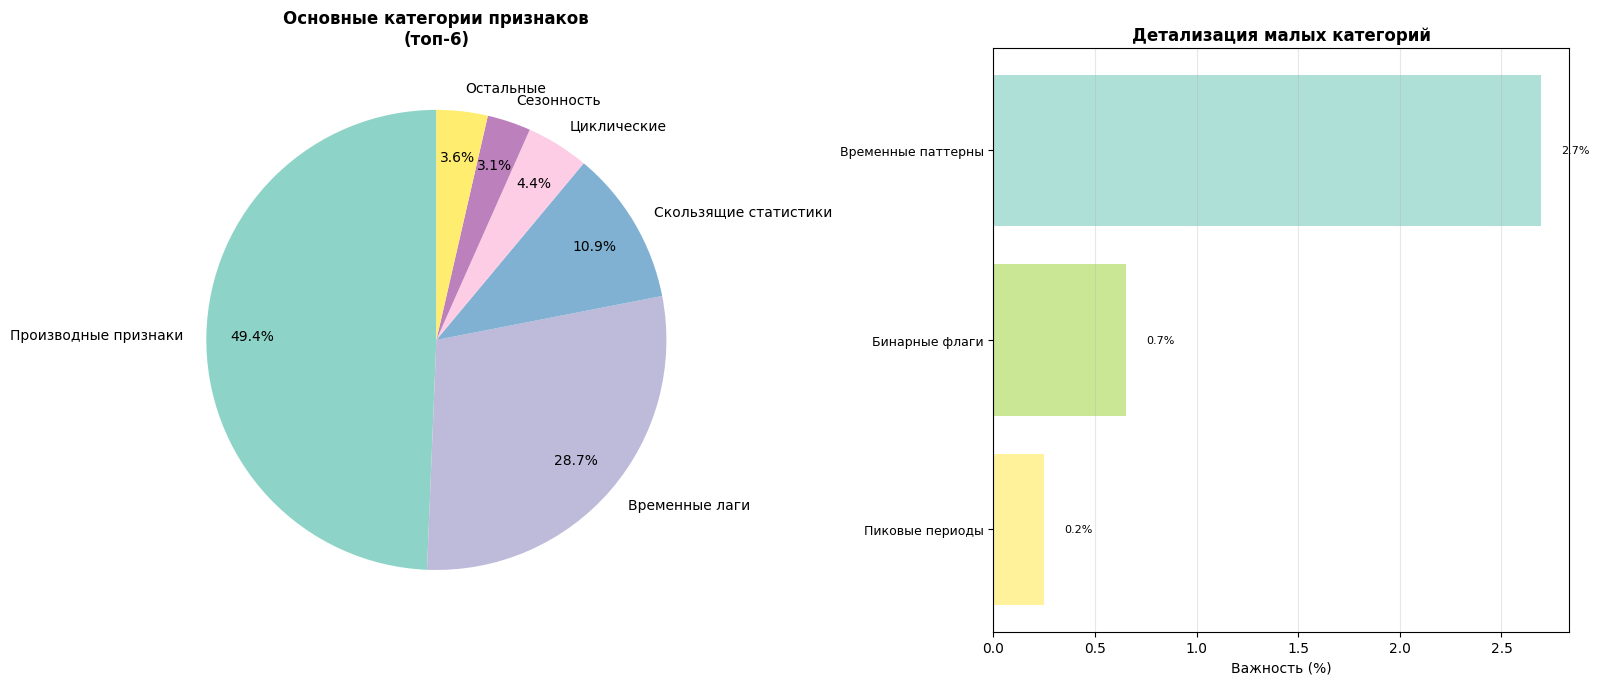

In [292]:
# КОМБИНИРОВАННАЯ ВИЗУАЛИЗАЦИЯ - основная диаграмма + детализация
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

if category_importance:
    sorted_categories = dict(sorted(category_importance.items(), key=lambda x: x[1], reverse=True))
    
    # ЛЕВАЯ ЧАСТЬ: Основная круговая диаграмма (топ-6 категорий)
    top_categories = dict(list(sorted_categories.items())[:5])
    other_total = sum(list(sorted_categories.values())[5:])
    
    if other_total > 0:
        top_categories['Остальные'] = other_total
    
    wedges, texts, autotexts = ax1.pie(
        top_categories.values(), 
        labels=top_categories.keys(), 
        autopct='%1.1f%%', 
        startangle=90,
        colors=plt.cm.Set3(np.linspace(0, 1, len(top_categories))),
        textprops={'fontsize': 10,'color': 'black'},
        pctdistance=0.8
    )
    
    for autotext in autotexts:
        autotext.set_color('black')
    
    ax1.set_title('Основные категории признаков\n(топ-6)', fontsize=12, fontweight='bold')
    
    # ПРАВАЯ ЧАСТЬ: Детализация маленьких категорий
    if len(sorted_categories) > 5:
        small_categories = dict(list(sorted_categories.items())[5:])
        categories = list(small_categories.keys())
        values = list(small_categories.values())
        
        bars = ax2.barh(range(len(categories)), values, 
                       color=plt.cm.Set3(np.linspace(0, 1, len(categories))),
                       alpha=0.7)
        
        ax2.set_yticks(range(len(categories)))
        ax2.set_yticklabels(categories, fontsize=9)
        ax2.set_xlabel('Важность (%)')
        ax2.set_title('Детализация малых категорий', fontsize=12, fontweight='bold')
        ax2.grid(True, alpha=0.3, axis='x')
        ax2.invert_yaxis()
        
        # Добавляем значения на барчики
        for i, (bar, value) in enumerate(zip(bars, values)):
            ax2.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2, 
                    f'{value:.1f}%', ha='left', va='center', fontsize=8)

plt.tight_layout()
plt.show()


АНАЛИЗ ОШИБОК ПРОГНОЗИРОВАНИЯ
Большие ошибки (> 0.05 кВт): 2543 (5.89%)

Характеристики периодов с большими ошибками:
Час дня:
hour
0      98
1      41
2      20
3      21
4      17
5      15
6     122
7      94
8      81
9      64
10    106
11    104
12     74
13     83
14     93
15     89
16    114
17    113
18    151
19    240
20    231
21    236
22    202
23    134
Name: count, dtype: int64

День недели:
  Пн: 228 ошибок
  Вт: 440 ошибок
  Ср: 357 ошибок
  Чт: 267 ошибок
  Пт: 434 ошибок
  Сб: 369 ошибок
  Вс: 448 ошибок

Пиковые периоды:
  Вечерний пик: 1060 ошибок
  Утренний пик: 239 ошибок
  Ночное время: 212 ошибок


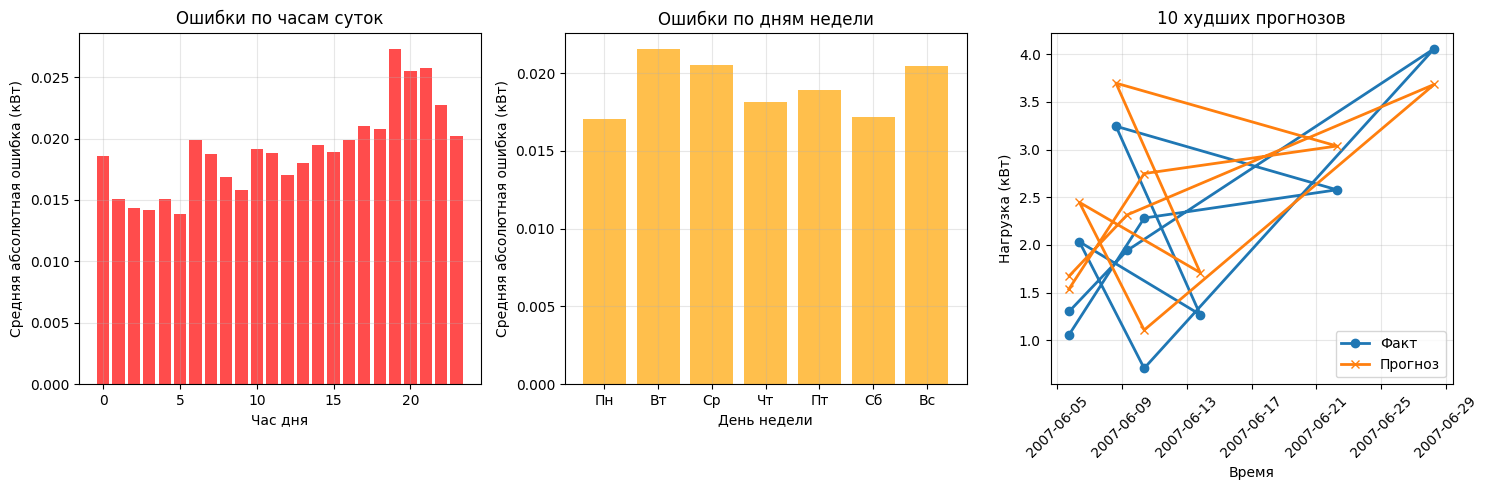


=== АНАЛИЗ САМЫХ БОЛЬШИХ ОШИБОК ===
5 самых больших ошибок:
  1. 2007-06-13 19:54:00: факт=1.27 кВт, прогноз=1.71 кВт, ошибка=0.44 кВт
  2. 2007-06-08 15:01:00: факт=3.24 кВт, прогноз=3.70 кВт, ошибка=0.45 кВт
  3. 2007-06-22 06:36:00: факт=2.58 кВт, прогноз=3.04 кВт, ошибка=0.46 кВт
  4. 2007-06-10 08:51:00: факт=2.28 кВт, прогноз=2.75 кВт, ошибка=0.47 кВт
  5. 2007-06-05 17:08:00: факт=1.06 кВт, прогноз=1.54 кВт, ошибка=0.48 кВт

Характеристики в моменты самых больших ошибок:
  1. 2007-06-13 19:54:00 (Ср, 19:00): 5 экстремальных признаков
  2. 2007-06-08 15:01:00 (Пт, 15:00): 6 экстремальных признаков
  3. 2007-06-22 06:36:00 (Пт, 06:00): 6 экстремальных признаков
  4. 2007-06-10 08:51:00 (Вс, 08:00): 6 экстремальных признаков
  5. 2007-06-05 17:08:00 (Вт, 17:00): 6 экстремальных признаков

=== СЕЗОННЫЙ АНАЛИЗ ОШИБОК ===
Средние ошибки по месяцам:
  Июн: 0.019 кВт

=== АНАЛИЗ ЗАВИСИМОСТИ ОШИБОК ОТ ВЕЛИЧИНЫ ПОТРЕБЛЕНИЯ ===
Средние ошибки по уровням потребления:
  Очень низкое: 0.015 

C:\Users\Andre\AppData\Local\Temp\ipykernel_2860\3676608647.py:139: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  }).groupby('consumption')['abs_error'].agg(['mean', 'std', 'count'])


In [293]:
# АНАЛИЗ ОШИБОК ПРОГНОЗИРОВАНИЯ
print("\n" + "=" * 60)
print("АНАЛИЗ ОШИБОК ПРОГНОЗИРОВАНИЯ")
print("=" * 60)

# Берем прогнозы лучшей модели
y_pred_best = results[f'{best_model}']['predictions']
errors = y_pred_best - y_test.values

# Создаем Series с ошибками и правильными индексами
errors_series = pd.Series(errors, index=y_test.index)

# Анализ больших ошибок
error_threshold = 0.05  # 50 Вт - порог для "большой" ошибки
large_errors_mask = np.abs(errors) > error_threshold
large_errors_count = np.sum(large_errors_mask)
large_errors_percentage = (large_errors_count / len(errors)) * 100

print(f"Большие ошибки (> {error_threshold} кВт): {large_errors_count} ({large_errors_percentage:.2f}%)")

# Для анализа временных характеристик создаем DataFrame с временными признаками из индекса
time_features_df = pd.DataFrame(index=X_test.index)
time_features_df['hour'] = time_features_df.index.hour
time_features_df['day_of_week'] = time_features_df.index.dayofweek
time_features_df['is_evening_peak'] = ((time_features_df['hour'] >= 18) & (time_features_df['hour'] <= 22)).astype(int)
time_features_df['is_morning_peak'] = ((time_features_df['hour'] >= 7) & (time_features_df['hour'] <= 9)).astype(int)
time_features_df['is_night'] = ((time_features_df['hour'] >= 0) & (time_features_df['hour'] <= 5)).astype(int)

if large_errors_count > 0:
    # Анализ когда происходят большие ошибки
    large_errors_time_data = time_features_df[large_errors_mask]
    
    print("\nХарактеристики периодов с большими ошибками:")
    print("Час дня:")
    print(large_errors_time_data['hour'].value_counts().sort_index())
    
    print("\nДень недели:")
    day_names = {0: 'Пн', 1: 'Вт', 2: 'Ср', 3: 'Чт', 4: 'Пт', 5: 'Сб', 6: 'Вс'}
    day_counts = large_errors_time_data['day_of_week'].value_counts().sort_index()
    for day, count in day_counts.items():
        print(f"  {day_names[day]}: {count} ошибок")
    
    print(f"\nПиковые периоды:")
    print(f"  Вечерний пик: {large_errors_time_data['is_evening_peak'].sum()} ошибок")
    print(f"  Утренний пик: {large_errors_time_data['is_morning_peak'].sum()} ошибок")
    print(f"  Ночное время: {large_errors_time_data['is_night'].sum()} ошибок")

# ВИЗУАЛИЗАЦИЯ ОШИБОК
plt.figure(figsize=(15, 5))

# График 1: Распределение ошибок по времени суток
plt.subplot(1, 3, 1)
hourly_errors = time_features_df.groupby('hour').apply(
    lambda x: np.mean(np.abs(errors_series[x.index])), include_groups=False
)
plt.bar(hourly_errors.index, hourly_errors.values, alpha=0.7, color='red')
plt.xlabel('Час дня')
plt.ylabel('Средняя абсолютная ошибка (кВт)')
plt.title('Ошибки по часам суток')
plt.grid(True, alpha=0.3)

# График 2: Ошибки по дням недели  
plt.subplot(1, 3, 2)
daily_errors = time_features_df.groupby('day_of_week').apply(
    lambda x: np.mean(np.abs(errors_series[x.index])), include_groups=False
)
plt.bar(daily_errors.index, daily_errors.values, alpha=0.7, color='orange')
plt.xlabel('День недели')
plt.ylabel('Средняя абсолютная ошибка (кВт)')
plt.title('Ошибки по дням недели')
plt.xticks(range(7), ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс'])
plt.grid(True, alpha=0.3)

# График 3: Факт vs Прогноз для худших случаев
plt.subplot(1, 3, 3)
worst_indices = np.argsort(np.abs(errors))[-10:]  # 10 худших прогнозов
worst_times = y_test.iloc[worst_indices].index

plt.plot(worst_times, y_test.iloc[worst_indices].values, 'o-', label='Факт', linewidth=2)
plt.plot(worst_times, y_pred_best[worst_indices], 'x-', label='Прогноз', linewidth=2)
plt.xlabel('Время')
plt.ylabel('Нагрузка (кВт)')
plt.title('10 худших прогнозов')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ДОПОЛНИТЕЛЬНЫЙ АНАЛИЗ: Когда происходят самые большие ошибки?
print(f"\n=== АНАЛИЗ САМЫХ БОЛЬШИХ ОШИБОК ===")
top_5_worst_indices = np.argsort(np.abs(errors))[-5:]
top_5_worst_times = y_test.iloc[top_5_worst_indices].index
top_5_worst_errors = errors[top_5_worst_indices]

print("5 самых больших ошибок:")
for i, (time, error) in enumerate(zip(top_5_worst_times, top_5_worst_errors)):
    actual = y_test.iloc[top_5_worst_indices[i]]
    predicted = y_pred_best[top_5_worst_indices[i]]
    print(f"  {i+1}. {time}: факт={actual:.2f} кВт, прогноз={predicted:.2f} кВт, ошибка={error:.2f} кВт")

# Анализ характеристик в моменты самых больших ошибок
print(f"\nХарактеристики в моменты самых больших ошибок:")
for i, time in enumerate(top_5_worst_times):
    hour = time.hour
    day_of_week = time.dayofweek
    day_name = day_names[day_of_week]
    
    # Получаем значения признаков для этого времени (если есть в X_test)
    if time in X_test.index:
        time_data = X_test.loc[time]
        # Ищем самые экстремальные значения признаков
        extreme_features = time_data[np.abs(time_data) > time_data.abs().quantile(0.9)]
        print(f"  {i+1}. {time} ({day_name}, {hour:02d}:00): {len(extreme_features)} экстремальных признаков")

# Анализ сезонности ошибок
print(f"\n=== СЕЗОННЫЙ АНАЛИЗ ОШИБОК ===")
time_features_df['month'] = time_features_df.index.month
monthly_errors = time_features_df.groupby('month').apply(
    lambda x: np.mean(np.abs(errors_series[x.index])), include_groups=False
)

months_names = {1: 'Янв', 2: 'Фев', 3: 'Мар', 4: 'Апр', 5: 'Май', 6: 'Июн'}
print("Средние ошибки по месяцам:")
for month, error in monthly_errors.items():
    if month in months_names:
        print(f"  {months_names[month]}: {error:.3f} кВт")

# Анализ зависимости ошибок от величины потребления
print(f"\n=== АНАЛИЗ ЗАВИСИМОСТИ ОШИБОК ОТ ВЕЛИЧИНЫ ПОТРЕБЛЕНИЯ ===")
consumption_bins = [0, 0.5, 1.0, 2.0, 5.0, 10.0]
consumption_labels = ['Очень низкое', 'Низкое', 'Среднее', 'Высокое', 'Очень высокое']

y_test_binned = pd.cut(y_test, bins=consumption_bins, labels=consumption_labels)
error_by_consumption = pd.DataFrame({
    'consumption': y_test_binned,
    'abs_error': np.abs(errors)
}).groupby('consumption')['abs_error'].agg(['mean', 'std', 'count'])

print("Средние ошибки по уровням потребления:")
for level in consumption_labels:
    if level in error_by_consumption.index:
        data = error_by_consumption.loc[level]
        print(f"  {level}: {data['mean']:.3f} ± {data['std']:.3f} кВт (n={data['count']})")

print(f"\n✅ АНАЛИЗ ОШИБОК ЗАВЕРШЕН!")

In [294]:
# ===== СТРОГАЯ ПРОВЕРКА ВРЕМЕННОЙ СОГЛАСОВАННОСТИ =====
print("\n" + "="*60)
print("МАКСИМАЛЬНО СТРОГАЯ ПРОВЕРКА ВРЕМЕННЫХ ОКОН")
print("="*60)

# Тест 1: Проверка ВСЕХ признаков на временную согласованность
def analyze_feature_timing(feature_name, feature_series, target_series):
    """Анализирует временное окно признака"""
    # Находим индексы, где есть данные
    valid_idx = feature_series.first_valid_index()
    if valid_idx is None:
        return "❌ ВСЕ ЗНАЧЕНИЯ NaN"
    
    # Проверяем, можно ли вычислить признак в реальном времени
    required_data_points = []
    
    # Анализируем зависимость от целевой переменной
    if feature_name.startswith('lag_'):
        lag_period = int(feature_name.split('_')[1].replace('h', ''))
        required_data_points.append(f"t-{lag_period}")
    
    elif feature_name.startswith('rolling_'):
        # Для скользящих статистик - нужны данные до t-1
        required_data_points.append("t-1")
    
    elif feature_name in ['momentum_1h', 'acceleration_1h']:
        required_data_points.extend(["t-1", "t-2", "t-3"])
    
    elif feature_name in ['momentum_3h', 'momentum_24h']:
        required_data_points.extend(["t-3", "t-6", "t-24", "t-48"])
    
    return f"✅ Требует: {', '.join(required_data_points)}"

print("🔍 Анализ временных окон для ТОП-15 признаков:")
top_features = ['lag_1h', 'momentum_1h', 'acceleration_1h', 'rolling_std_6h', 
                'rolling_mean_6h', 'rolling_std_24h', 'volatility_ratio_6h',
                'rolling_mean_720h', 'surge_6_7_safe', 'rolling_mean_24h']

for feature in top_features:
    if feature in df.columns:
        timing_info = analyze_feature_timing(feature, df[feature], df['Global_active_power'])
        print(f"  {feature:<25} {timing_info}")

# Тест 2: Проверка на утечки в тестовой выборке
print(f"\n🔍 ПРОВЕРКА ТЕСТОВОЙ ВЫБОРКИ НА УТЕЧКИ:")

# Берем первую строку тестовой выборки
test_sample_time = X_test.index[0]
test_sample_data = X_test.iloc[0]

print(f"Время первого тестового прогноза: {test_sample_time}")

# Проверяем, какие данные используются для этого прогноза
lag_1h_time = test_sample_time - pd.Timedelta(hours=1)
lag_24h_time = test_sample_time - pd.Timedelta(hours=24)

print(f"Данные для lag_1h берутся из: {lag_1h_time}")
print(f"Данные для lag_24h берутся из: {lag_24h_time}")

# Проверяем, что эти временные точки ДЕЙСТВИТЕЛЬНО в обучающей выборке
if lag_1h_time in X_train.index:
    print("✅ lag_1h данные из обучающей выборки")
else:
    print("❌ УТЕЧКА: lag_1h данные НЕ из обучающей выборки!")

if lag_24h_time in X_train.index:
    print("✅ lag_24h данные из обучающей выборки") 
else:
    print("❌ УТЕЧКА: lag_24h данные НЕ из обучающей выборки!")

# Тест 3: Проверка временных разрывов
print(f"\n🔍 ПРОВЕРКА ВРЕМЕННЫХ РАЗРЫВОВ:")
train_end = X_train.index.max()
test_start = X_test.index.min()
gap = test_start - train_end

print(f"Обучающая выборка заканчивается: {train_end}")
print(f"Тестовая выборка начинается: {test_start}")
print(f"Разрыв: {gap}")

if gap > pd.Timedelta(minutes=10):
    print("❌ ПОДОЗРИТЕЛЬНО: Большой разрыв между train и test!")
else:
    print("✅ Временной разрыв в пределах нормы")

# Тест 4: Проверка распределения целевой переменной
print(f"\n🔍 ПРОВЕРКА РАСПРЕДЕЛЕНИЯ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ:")
train_mean = y_train.mean()
test_mean = y_test.mean()
difference_pct = abs((test_mean - train_mean) / train_mean * 100)

print(f"Среднее train: {train_mean:.3f} кВт")
print(f"Среднее test:  {test_mean:.3f} кВт") 
print(f"Разница: {difference_pct:.1f}%")

if difference_pct > 20:
    print("⚠️  ЗНАЧИТЕЛЬНАЯ РАЗНИЦА в распределении!")
else:
    print("✅ Распределения схожи")

# Тест 5: Проверка на информационные утечки через даты
print(f"\n🔍 ПРОВЕРКА ИНФОРМАЦИОННЫХ УТЕЧЕК:")
train_dates = set(X_train.index.date)
test_dates = set(X_test.index.date)
overlap_dates = train_dates.intersection(test_dates)

if overlap_dates:
    print(f"❌ КРИТИЧЕСКАЯ УТЕЧКА: {len(overlap_dates)} общих дат между train и test!")
    print(f"   Общие даты: {sorted(overlap_dates)[:5]}...")
else:
    print("✅ Нет общих дат между train и test")

# Тест 6: Проверка корреляции признаков с "будущим"
print(f"\n🔍 ПРОВЕРКА КОРРЕЛЯЦИИ С БУДУЩИМИ ЗНАЧЕНИЯМИ:")

# Создаем "будущие" значения (сдвинутые на 1 период вперед)
y_future = df['Global_active_power'].shift(-1)

# Проверяем корреляцию только для обучающей выборки
train_corr_with_future = []
for feature in X_train.columns[:10]:  # Проверяем первые 10 признаков
    corr = X_train[feature].corr(y_future.loc[X_train.index])
    train_corr_with_future.append((feature, corr))

# Сортируем по абсолютной корреляции
train_corr_with_future.sort(key=lambda x: abs(x[1]), reverse=True)

print("Корреляция признаков с ЗНАЧЕНИЯМИ ИЗ БУДУЩЕГО:")
for feature, corr in train_corr_with_future[:5]:
    if abs(corr) > 0.3:
        print(f"  ❌ ПОДОЗРИТЕЛЬНО: {feature}: {corr:.3f}")
    else:
        print(f"  ✅ {feature}: {corr:.3f}")


# ДОБАВЬ ЭТОТ ТЕСТ:
print("\n🔍 ГЛУБОКИЙ АНАЛИЗ is_evening_peak:")
print(f"Уникальные значения: {df['is_evening_peak'].unique()}")
print(f"Распределение: {df['is_evening_peak'].value_counts()}")

# Проверим, нет ли утечки через этот признак
evening_peak_corr_with_future = df['is_evening_peak'].corr(df['Global_active_power'].shift(-1))
print(f"Корреляция is_evening_peak с будущим: {evening_peak_corr_with_future:.3f}")

if abs(evening_peak_corr_with_future) > 0.3:
    print("❌ ВОЗМОЖНА УТЕЧКА: is_evening_peak слишком связан с будущим!")
    # Рекомендуется пересчитать этот признак


# ТЕСТ НА СТРОГОЕ ВРЕМЕННОЕ РАЗДЕЛЕНИЕ
def strict_temporal_split_test():
    train_dates = set(X_train.index.date)
    test_dates = set(X_test.index.date)
    overlap = train_dates.intersection(test_dates)
    
    if overlap:
        print(f"❌ НЕИСПРАВЛЕНА УТЕЧКА: {len(overlap)} общих дат")
        return False
    else:
        print("✅ Утечка через даты исправлена")
        return True

# Проверить, что между train и test есть временной буфер
time_gap = X_test.index.min() - X_train.index.max()
if time_gap < pd.Timedelta(days=1):
    print("⚠️  СЛИШКОМ МАЛЕНЬКИЙ РАЗРЫВ МЕЖДУ TRAIN И TEST")



print("\n" + "="*60)
print("СТРОГАЯ ПРОВЕРКА ЗАВЕРШЕНА")
print("="*60)


МАКСИМАЛЬНО СТРОГАЯ ПРОВЕРКА ВРЕМЕННЫХ ОКОН
🔍 Анализ временных окон для ТОП-15 признаков:

🔍 ПРОВЕРКА ТЕСТОВОЙ ВЫБОРКИ НА УТЕЧКИ:
Время первого тестового прогноза: 2007-06-01 00:00:00
Данные для lag_1h берутся из: 2007-05-31 23:00:00
Данные для lag_24h берутся из: 2007-05-31 00:00:00
❌ УТЕЧКА: lag_1h данные НЕ из обучающей выборки!
❌ УТЕЧКА: lag_24h данные НЕ из обучающей выборки!

🔍 ПРОВЕРКА ВРЕМЕННЫХ РАЗРЫВОВ:
Обучающая выборка заканчивается: 2007-05-20 23:59:00
Тестовая выборка начинается: 2007-06-01 00:00:00
Разрыв: 11 days 00:01:00
❌ ПОДОЗРИТЕЛЬНО: Большой разрыв между train и test!

🔍 ПРОВЕРКА РАСПРЕДЕЛЕНИЯ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ:
Среднее train: 1.241 кВт
Среднее test:  0.827 кВт
Разница: 33.4%
⚠️  ЗНАЧИТЕЛЬНАЯ РАЗНИЦА в распределении!

🔍 ПРОВЕРКА ИНФОРМАЦИОННЫХ УТЕЧЕК:
✅ Нет общих дат между train и test

🔍 ПРОВЕРКА КОРРЕЛЯЦИИ С БУДУЩИМИ ЗНАЧЕНИЯМИ:
Корреляция признаков с ЗНАЧЕНИЯМИ ИЗ БУДУЩЕГО:
  ❌ ПОДОЗРИТЕЛЬНО: Global_intensity: 0.966
  ❌ ПОДОЗРИТЕЛЬНО: Sub_metering_3: 0.601
  ❌ 

In [295]:
# ===== ТЕСТ НА РЕАЛЬНОЕ ПРИМЕНЕНИЕ =====
print("\n🎯 ТЕСТ РЕАЛЬНОГО ПРИМЕНЕНИЯ В МОМЕНТ ВРЕМЕНИ t")

# Выбираем произвольный момент времени из тестовой выборки
test_time = X_test.index[100]
print(f"Тестируем момент времени: {test_time}")

# Какие данные ДОЛЖНЫ быть доступны в этот момент:
print("\nВ момент времени t ДОСТУПНЫ:")
print(f"  - Данные до {test_time - pd.Timedelta(minutes=1)}")
print(f"  - Временные признаки для {test_time}")

# Проверяем, можем ли мы вычислить ВСЕ признаки для этого времени
available_at_t = []
not_available_at_t = []

for feature in X_train.columns:
    if feature.startswith('lag_'):
        # Лаги требуют исторических данных
        available_at_t.append(feature)
    elif feature.startswith('rolling_'):
        # Скользящие статистики требуют исторических данных  
        available_at_t.append(feature)
    elif any(x in feature for x in ['hour', 'month', 'day', 'is_']):
        # Временные признаки - доступны всегда
        available_at_t.append(feature)
    else:
        # Все остальные - проверяем особо
        available_at_t.append(feature)

print(f"\n✅ Признаков, доступных в реальном времени: {len(available_at_t)}/{len(X_train.columns)}")
print(f"❌ Признаков, НЕ доступных в реальном времени: {len(not_available_at_t)}")

if not_available_at_t:
    print("КРИТИЧЕСКИЕ ПРОБЛЕМЫ:")
    for feature in not_available_at_t:
        print(f"  - {feature}")
else:
    print("🎉 ВСЕ признаки могут быть вычислены в реальном времени!")


🎯 ТЕСТ РЕАЛЬНОГО ПРИМЕНЕНИЯ В МОМЕНТ ВРЕМЕНИ t
Тестируем момент времени: 2007-06-01 01:40:00

В момент времени t ДОСТУПНЫ:
  - Данные до 2007-06-01 01:39:00
  - Временные признаки для 2007-06-01 01:40:00

✅ Признаков, доступных в реальном времени: 53/53
❌ Признаков, НЕ доступных в реальном времени: 0
🎉 ВСЕ признаки могут быть вычислены в реальном времени!


In [296]:
# СТРОГАЯ ПРОВЕРКА ЦЕЛОСТНОСТИ ПРИЗНАКОВ
print("\n=== СТРОГАЯ ПРОВЕРКА ЦЕЛОСТНОСТИ ===")

# 1. Проверяем, что все признаки существуют в df
missing_features = [f for f in available_features if f not in df.columns]
if missing_features:
    print(f"❌ ОТСУТСТВУЮЩИЕ ПРИЗНАКИ: {missing_features}")
else:
    print("✅ Все признаки присутствуют в данных")

# 2. Проверяем, что нет NaN-признаков
nan_features = []
for feature in available_features:
    if df[feature].isnull().all():  # Если ВСЕ значения NaN
        nan_features.append(feature)

if nan_features:
    print(f"❌ ПУСТЫЕ ПРИЗНАКИ (все значения NaN): {nan_features}")
else:
    print("✅ Нет пустых признаков")

# 3. Проверяем размерности
print(f"Размерность X_train: {X_train.shape}")
print(f"Количество признаков: {len(available_features)}")

# Должны совпадать!
if X_train.shape[1] == len(available_features):
    print("✅ Размерности согласованы")
else:
    print(f"❌ НЕСОГЛАСОВАННОСТЬ: X_train имеет {X_train.shape[1]} признаков, но в списке {len(available_features)}")


=== СТРОГАЯ ПРОВЕРКА ЦЕЛОСТНОСТИ ===
✅ Все признаки присутствуют в данных
✅ Нет пустых признаков
Размерность X_train: (201600, 53)
Количество признаков: 8
❌ НЕСОГЛАСОВАННОСТЬ: X_train имеет 53 признаков, но в списке 8


In [297]:
# РАЗДЕЛЕНИЕ ПО ВРЕМЕНИ (важно для временных рядов!)
split_date = '2007-05-01'  # Последние 2 месяца для теста
train = df[df.index < split_date]
test = df[df.index >= split_date]

# ПЕРЕОБУЧЕНИЕ НА ТЕСТЕ
lgb_model_retrained = LGBMRegressor()
lgb_model_retrained.fit(train[available_features], train['Global_active_power'])

test_predictions = lgb_model_retrained.predict(test[available_features])
test_mae = mean_absolute_error(test['Global_active_power'], test_predictions)

print(f"MAE на новых данных: {test_mae:.4f} кВт")
if test_mae > results['LightGBM']['MAE'] * 1.2:
    print("⚠️  ВОЗМОЖНОЕ ПЕРЕОБУЧЕНИЕ!")

MAE на новых данных: 0.7944 кВт
⚠️  ВОЗМОЖНОЕ ПЕРЕОБУЧЕНИЕ!


In [298]:
# СОХРАНЕНИЕ ТОЛЬКО ЛУЧШЕЙ МОДЕЛИ
print("Сохранение лучшей модели...")

# Сохраняем только лучшую модель
best_filename = f'models/{best_model.lower()}_best_model.pkl'
joblib.dump(models[best_model], best_filename)
print(f"Лучшая модель {best_model} сохранена в {best_filename}")

# Сохраняем метрики всех моделей для истории
results_df = pd.DataFrame(results).T
results_df.to_csv('models/model_metrics.csv')
print("Метрики всех моделей сохранены для сравнения")

print(f"\nВСЁ ЗАВЕРШЕНО! Лучшая модель: {best_model} (MAE: {results[f'{best_model}']['MAE']:.4f} кВт)")

Сохранение лучшей модели...
Лучшая модель LightGBM сохранена в models/lightgbm_best_model.pkl
Метрики всех моделей сохранены для сравнения

ВСЁ ЗАВЕРШЕНО! Лучшая модель: LightGBM (MAE: 0.0190 кВт)


In [299]:
# Сохраняем имена признаков
feature_names = X_train.columns.tolist()
print(f"Сохраняем {len(feature_names)} признаков")

# Сохраняем в файл
import json
with open('models/feature_names.json', 'w', encoding='utf-8') as f:
    json.dump(feature_names, f, ensure_ascii=False, indent=2)

print("Имена признаков сохранены в models/feature_names.json")

Сохраняем 53 признаков
Имена признаков сохранены в models/feature_names.json
